# Step 1 - Explore and understand the data

**Assignment 1: Housing Price Prediction** - Ames Housing, `SalePrice` regression.

This notebook covers **Step 1** of the workflow. Its job is not to build a model, but to
produce the *evidence* for the decisions made later in `02_modeling.ipynb`:

| What we look for here | Which later step it decides |
|---|---|
| variables and their true data types | Step 3 - which encoder each column gets |
| distribution of `SalePrice` | Step 6 - how to read RMSE; Q7 |
| missing values, and **what each one means** | Step 3 - imputation strategy |
| unusual values and patterns | Step 4 - what to drop |
| relationships with `SalePrice` | Step 4 - what to keep and engineer |

Every plot below exists to answer a specific question. The brief explicitly warns against
plotting "simply for the sake of visualization", so each figure is paired with the decision
it informs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/raw/AmesHousing.csv")

print(f"rows: {df.shape[0]:,}   columns: {df.shape[1]}")
df.head()

rows: 2,930   columns: 82


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 1.1 What does one row represent, and what types are there?

One row = **one residential property sale** in Ames, Iowa (2006-2010). The target is
`SalePrice` in US dollars.

In [2]:
df.info(verbose=False)

print("\nColumn dtypes:")
print(df.dtypes.value_counts().to_string())

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 82 entries, Order to SalePrice
dtypes: float64(11), int64(28), str(43)
memory usage: 1.8 MB

Column dtypes:
str        43
int64      28
float64    11


### Two columns are identifiers, not features

`Order` is just the row number and `PID` is the county parcel number. Neither carries
information about the *property*, so both are removed before modeling.

We verify this rather than assume it - if `Order` correlated with price it would mean the
file is sorted in some meaningful way, which would matter.

In [3]:
id_cols = ["Order", "PID"]

print("Unique values (should equal 2930 if they are pure identifiers):")
print(df[id_cols].nunique().to_string())

print("\nCorrelation with SalePrice:")
print(df[id_cols + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").round(3).to_string())

Unique values (should equal 2930 if they are pure identifiers):
Order    2930
PID      2930

Correlation with SalePrice:
Order   -0.031
PID     -0.247


**Finding - and a warning.** Both columns are unique per row, so neither generalises: a model
can only memorise them.

`Order` is harmless (r = -0.03). **`PID` is not: r = -0.25.** That is not a real relationship -
parcel numbers are assigned geographically, so `PID` is a crude proxy for *location*. A
decision tree would happily split on it and appear to learn something, while actually keying
off an administrative numbering scheme that will not transfer to any other town or year.

This is a good example of why "it correlates with the target" is not sufficient reason to keep
a feature. Both are dropped in Step 4; `Neighborhood` captures location honestly.

---

## 1.2 A number is not always a numerical measurement

The dataset guide warns about this directly. `MS SubClass` is stored as an integer but the
values are **building-type codes** (20 = 1-storey post-1946, 60 = 2-storey post-1946,
90 = duplex, ...).

If we let pandas' dtype decide, `select_dtypes(include=[np.number])` would sweep it into the
numeric pipeline and the model would learn that a duplex (90) is "one and a half times"
a 2-storey house (60). That is meaningless.

MS SubClass - stored as int64 but these are codes:
MS SubClass
20     1079
30      139
40        6
45       18
50      287
60      575
70      128
75       23
80      118
85       48
90      109
120     192
150       1
160     129
180      17
190      61


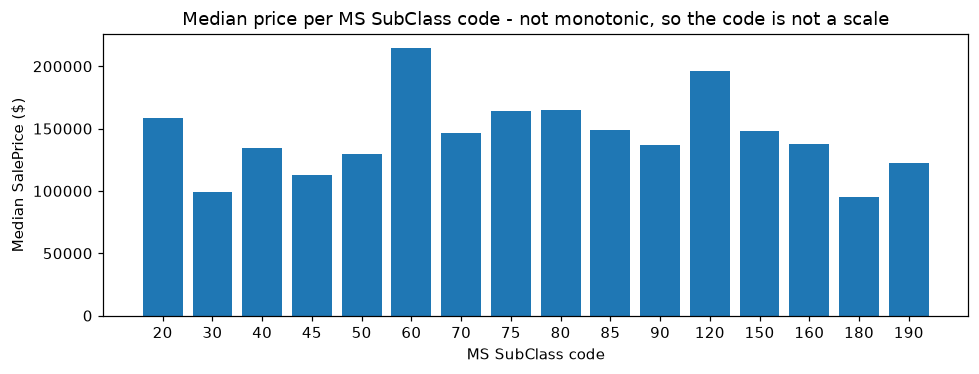

In [4]:
print("MS SubClass - stored as", df["MS SubClass"].dtype, "but these are codes:")
print(df["MS SubClass"].value_counts().sort_index().to_string())

# Median price per code: if the codes were a meaningful scale, price would move
# monotonically with the code number. It does not.
med = df.groupby("MS SubClass")["SalePrice"].median()

plt.figure(figsize=(9, 3.5))
plt.bar(med.index.astype(str), med.values)
plt.xlabel("MS SubClass code")
plt.ylabel("Median SalePrice ($)")
plt.title("Median price per MS SubClass code - not monotonic, so the code is not a scale")
plt.tight_layout()
plt.show()

**Finding.** Price does not increase with the code number, confirming the codes are
*nominal labels*. `MS SubClass` will be treated as categorical in Step 3.

Columns needing the same care: `Mo Sold` (month, cyclical), `Yr Sold`, `Year Built`,
`Year Remod/Add`, `Garage Yr Blt` (years, not quantities - better used as *ages*, see Step 4).

---

## 1.3 Distribution of the target, `SalePrice`

min      12789.0
25%     129500.0
50%     160000.0
mean    180796.0
75%     213500.0
max     755000.0

skewness            : 1.74
skewness of log(price): -0.01


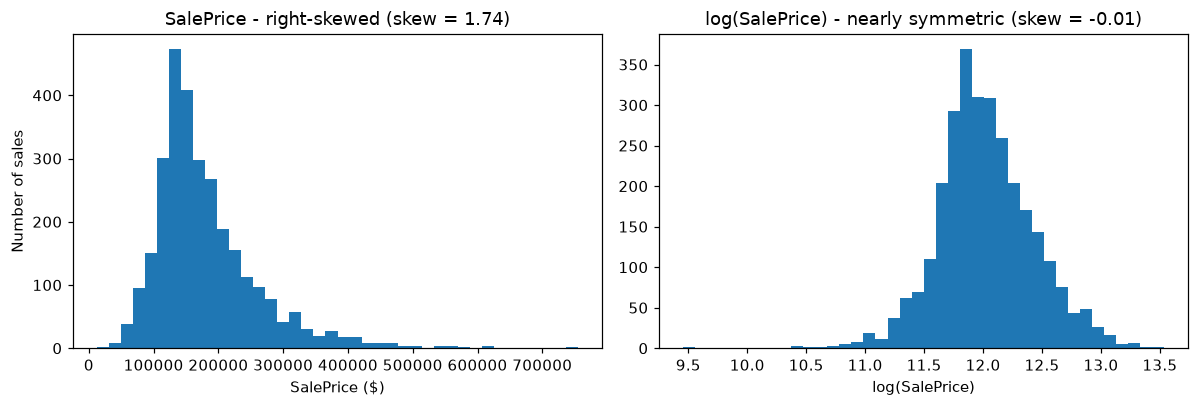

In [5]:
price = df["SalePrice"]

summary = price.describe()[["min", "25%", "50%", "mean", "75%", "max"]].round(0)
print(summary.to_string())
print(f"\nskewness            : {price.skew():.2f}")
print(f"skewness of log(price): {np.log(price).skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(price, bins=40)
ax[0].set_xlabel("SalePrice ($)"); ax[0].set_ylabel("Number of sales")
ax[0].set_title(f"SalePrice - right-skewed (skew = {price.skew():.2f})")

ax[1].hist(np.log(price), bins=40)
ax[1].set_xlabel("log(SalePrice)")
ax[1].set_title(f"log(SalePrice) - nearly symmetric (skew = {np.log(price).skew():.2f})")
plt.tight_layout(); plt.show()

**Finding (supports Q1 and Q7).**

- Prices run from \$12,789 to \$755,000, median \$160,000, mean \$180,796. Mean > median is
  the signature of a right tail.
- Skewness **1.74** - a long tail of expensive houses. A log transform brings it to **-0.01**,
  i.e. essentially symmetric.
- **Why this matters for the model:** linear regression minimises *squared* error, so the few
  very expensive houses dominate the fit. The model buys accuracy at the top by being wrong
  in the middle, where most houses are.
- We deliberately keep `SalePrice` untransformed in the main pipeline so that RMSE stays in
  dollars and is directly interpretable in the Step 6 table. Log-transforming the target is
  revisited in Step 6 as the concrete answer to **Q7**.

---

## 1.4 Missing values - and what each one *means*

27 columns contain `NaN`. The critical insight from the dataset guide is that `NaN` carries
**two completely different meanings**, and pandas shows both identically:

1. **The feature is absent.** No fireplace → `Fireplace Qu` is NaN. This is *information*.
2. **The value was not recorded.** `Lot Frontage` NaN → the measurement is simply unknown.

Treating these the same way would be the single biggest preprocessing mistake available here.
Dropping every column above some NaN threshold would throw away "this house has no pool",
which is a perfectly real and useful fact.

In [6]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)

missing = pd.DataFrame({
    "Missing": na,
    "Percent": (na / len(df) * 100).round(1),
})
print(f"{len(na)} columns contain missing values\n")
missing

27 columns contain missing values



,Missing,Percent
Pool QC,2917,99.6
Misc Feature,2824,96.4
Alley,2732,93.2
Fence,2358,80.5
Mas Vnr Type,1775,60.6
Fireplace Qu,1422,48.5
Lot Frontage,490,16.7
Garage Qual,159,5.4
Garage Cond,159,5.4
Garage Yr Blt,159,5.4


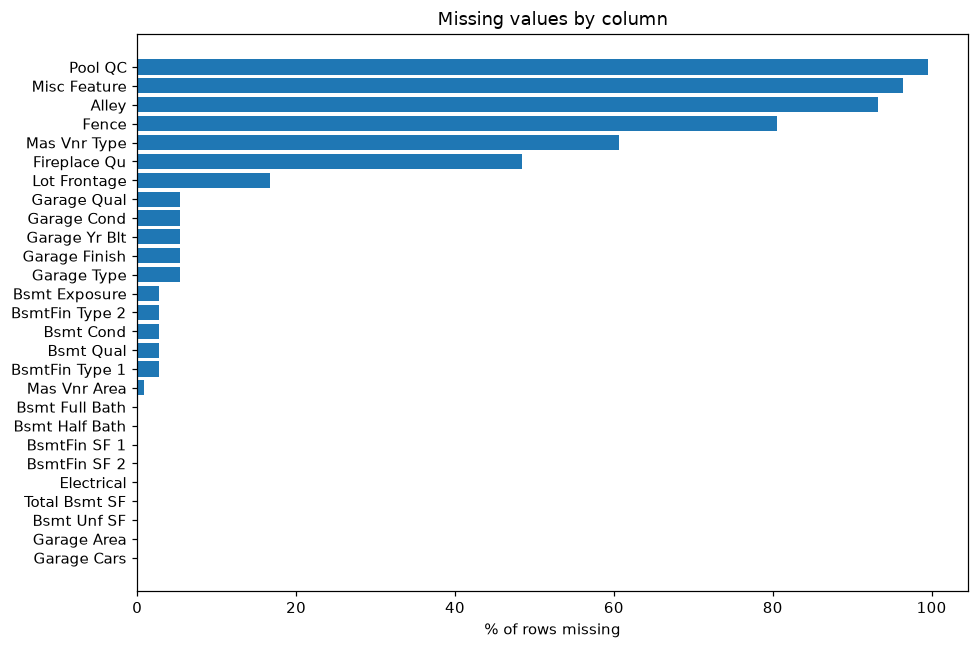

In [7]:
plt.figure(figsize=(9, 6))
plt.barh(missing.index[::-1], missing["Percent"][::-1])
plt.xlabel("% of rows missing")
plt.title("Missing values by column")
plt.tight_layout(); plt.show()

### Verifying the guide's claim instead of trusting it

The guide says garage columns are missing "usually because there is no garage". That is a
claim we can **test**: if it is true, those same rows should have `Garage Area == 0`.

The same check applies to the basement block and to `Mas Vnr Type`.

In [8]:
garage_cat = ["Garage Type", "Garage Finish", "Garage Qual", "Garage Cond", "Garage Yr Blt"]
bsmt_cat   = ["Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"]

no_garage = df[garage_cat].isna().all(axis=1)
no_bsmt   = df[bsmt_cat].isna().all(axis=1)

print("GARAGE")
print(f"  rows with every garage category missing : {no_garage.sum()}")
print(f"  ...of those, Garage Area == 0           : {(df.loc[no_garage, 'Garage Area'] == 0).sum()}")
print(f"  rows with Garage Qual missing           : {df['Garage Qual'].isna().sum()}")

print("\nBASEMENT")
print(f"  rows with every basement category missing: {no_bsmt.sum()}")
print(f"  ...of those, Total Bsmt SF == 0          : {(df.loc[no_bsmt, 'Total Bsmt SF'] == 0).sum()}")

mv = df["Mas Vnr Type"].isna()
print("\nMASONRY VENEER  (Mas Vnr Type is missing in 60.6% of rows)")
print(f"  missing type & Area == 0  -> genuinely no veneer : {(mv & (df['Mas Vnr Area'] == 0)).sum()}")
print(f"  missing type & Area  > 0  -> veneer, type unknown: {(mv & (df['Mas Vnr Area'] > 0)).sum()}")
print(f"  missing type & Area  NaN                         : {(mv & df['Mas Vnr Area'].isna()).sum()}")

GARAGE
  rows with every garage category missing : 157
  ...of those, Garage Area == 0           : 157
  rows with Garage Qual missing           : 159

BASEMENT
  rows with every basement category missing: 80
  ...of those, Total Bsmt SF == 0          : 79

MASONRY VENEER  (Mas Vnr Type is missing in 60.6% of rows)
  missing type & Area == 0  -> genuinely no veneer : 1745
  missing type & Area  > 0  -> veneer, type unknown: 7
  missing type & Area  NaN                         : 23


**Finding (strong Q1 / Q4 evidence).**

- **157** houses have every garage category missing, and **all 157** have `Garage Area == 0`.
  The guide is confirmed: NaN = *no garage*. Note `Garage Qual` has **159** NaN - so exactly
  **2** houses do have a garage whose quality was never recorded. Both situations exist in the
  same column, exactly as the guide describes.
- **80** houses have every basement category missing; **79** have `Total Bsmt SF == 0`. One
  house has a basement with unrecorded quality.
- `Mas Vnr Type` looks alarming at 60.6% missing, but **1,745** of those rows have
  `Mas Vnr Area == 0` - they simply have no masonry veneer. Only **7** are true unknowns.

**Decision carried to Step 3:** split the missing columns into two groups.

| Group | Columns | Treatment |
|---|---|---|
| NaN = absence | `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Fireplace Qu`, garage block, basement block, `Mas Vnr Type` | fill with an explicit `"None"` category (or `0`) - the absence is a real signal |
| NaN = unknown | `Lot Frontage`, `Mas Vnr Area`, `Electrical`, and the single-row stragglers | impute from the **training** data (median / most frequent) |

---

## 1.5 Which numerical features relate to price?

Correlation is a **clue, not proof of causation** - and it only detects *linear* relationships.
We use it to shortlist, then look at the actual scatter plots.

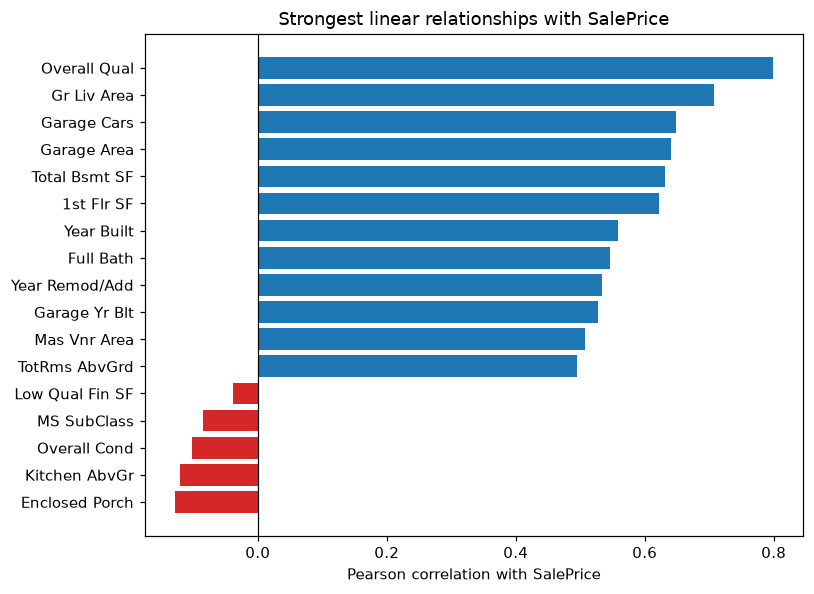

Overall Qual      0.799
Gr Liv Area       0.707
Garage Cars       0.648
Garage Area       0.640
Total Bsmt SF     0.632
1st Flr SF        0.622
Year Built        0.558
Full Bath         0.546
Year Remod/Add    0.533
Garage Yr Blt     0.527
Mas Vnr Area      0.508


In [9]:
corr = df.drop(columns=id_cols).corr(numeric_only=True)["SalePrice"].drop("SalePrice")
corr = corr.sort_values(ascending=False)

top = pd.concat([corr.head(12), corr.tail(5)]).round(3)

plt.figure(figsize=(7.5, 5.5))
colors = ["tab:blue" if v > 0 else "tab:red" for v in top.values]
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Pearson correlation with SalePrice")
plt.title("Strongest linear relationships with SalePrice")
plt.tight_layout(); plt.show()

print(corr[abs(corr) > 0.5].round(3).to_string())

**Finding (supports Q2).** The strongest numerical predictors are all measures of **size** and
**quality**:

| Feature | r | Why it makes sense |
|---|---|---|
| `Overall Qual` | 0.80 | overall material/finish rating, 1-10 |
| `Gr Liv Area` | 0.71 | above-ground living area |
| `Garage Cars` / `Garage Area` | 0.65 / 0.64 | these two measure the *same thing* twice |
| `Total Bsmt SF` / `1st Flr SF` | 0.63 / 0.62 | more size |
| `Year Built` / `Year Remod/Add` | 0.56 / 0.53 | newer houses sell higher |

Note the redundancy: `Garage Cars` and `Garage Area` are near-duplicates, and
`Total Bsmt SF ≈ BsmtFin SF 1 + BsmtFin SF 2 + Bsmt Unf SF`. This motivates the combined
size feature created in Step 4.

`Year Built` correlating with price also tells us the *year* columns are better expressed as
**ages relative to the sale year** - a house built in 1990 and sold in 1991 is new; the same
house sold in 2010 is not.

---

## 1.6 Do the top relationships actually look usable?

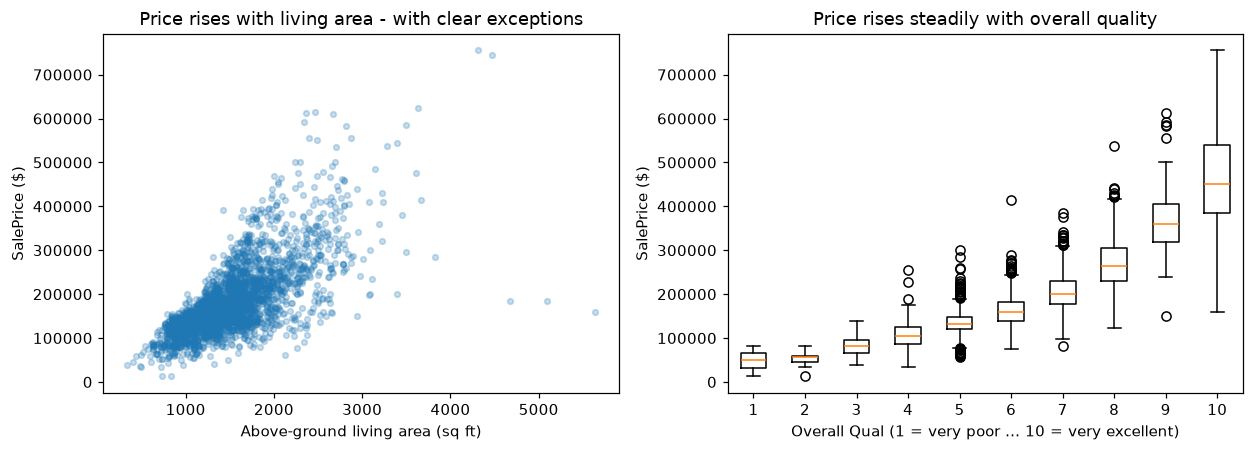

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax[0].scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.25, s=14)
ax[0].set_xlabel("Above-ground living area (sq ft)")
ax[0].set_ylabel("SalePrice ($)")
ax[0].set_title("Price rises with living area - with clear exceptions")

qual = [df.loc[df["Overall Qual"] == q, "SalePrice"] for q in sorted(df["Overall Qual"].unique())]
ax[1].boxplot(qual, tick_labels=sorted(df["Overall Qual"].unique()))
ax[1].set_xlabel("Overall Qual (1 = very poor ... 10 = very excellent)")
ax[1].set_ylabel("SalePrice ($)")
ax[1].set_title("Price rises steadily with overall quality")

plt.tight_layout(); plt.show()

**Finding.** Both relationships are real and strong. `Overall Qual` is *monotonic* - each step
up in rating raises the median price - which is exactly why ordered ratings should keep their
order when encoded (Step 3) rather than being one-hot encoded into unordered dummies.

The living-area scatter shows something else: a handful of very large houses sold cheaply.
We investigate those next.

---

## 1.7 Unusual observations

The scatter above shows four or five points far to the right that break the pattern. The Ames
dataset's author documented these.

In [11]:
big = df[df["Gr Liv Area"] > 4000][
    ["Gr Liv Area", "SalePrice", "Overall Qual", "Sale Condition", "Yr Sold"]
].sort_values("Gr Liv Area", ascending=False)
print("Houses larger than 4,000 sq ft:")
print(big.to_string())

print("\nSale Condition across the whole dataset:")
print(df["Sale Condition"].value_counts().to_string())

Houses larger than 4,000 sq ft:
      Gr Liv Area  SalePrice  Overall Qual Sale Condition  Yr Sold
1498         5642     160000            10        Partial     2008
2180         5095     183850            10        Partial     2007
2181         4676     184750            10        Partial     2007
1760         4476     745000            10        Abnorml     2007
1767         4316     755000            10         Normal     2007

Sale Condition across the whole dataset:
Sale Condition
Normal     2413
Partial     245
Abnorml     190
Family       46
Alloca       24
AdjLand      12


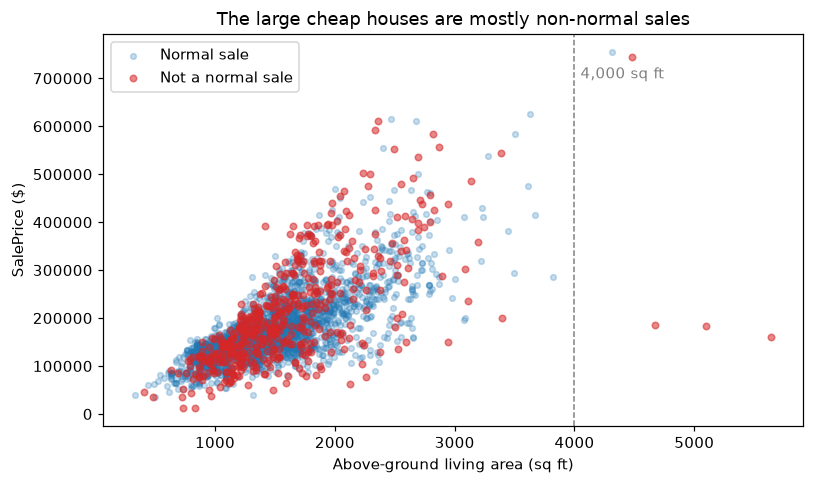

In [12]:
plt.figure(figsize=(7.5, 4.5))
normal = df["Sale Condition"] == "Normal"
plt.scatter(df.loc[normal, "Gr Liv Area"], df.loc[normal, "SalePrice"],
            alpha=0.25, s=14, label="Normal sale")
plt.scatter(df.loc[~normal, "Gr Liv Area"], df.loc[~normal, "SalePrice"],
            alpha=0.55, s=18, color="tab:red", label="Not a normal sale")
plt.axvline(4000, color="grey", ls="--", lw=1)
plt.text(4050, 700000, "4,000 sq ft", color="grey")
plt.xlabel("Above-ground living area (sq ft)")
plt.ylabel("SalePrice ($)")
plt.title("The large cheap houses are mostly non-normal sales")
plt.legend(); plt.tight_layout(); plt.show()

**Finding (supports Q1 and Q5).** All five houses above 4,000 sq ft have `Overall Qual == 10`,
but they split into two very different groups:

- **Three are `Partial` sales** - the house was incomplete when last assessed. One is
  5,642 sq ft sold for \$160,000, which is not a market price for a house of that size; it is
  a different kind of transaction. These three are the points that break the trend.
- **Two sold for \$745,000 and \$755,000** and sit exactly where the trend predicts. One is
  `Normal`, one is `Abnorml` - so being flagged non-normal does not automatically make a row
  bad. `Abnorml` covers foreclosures and trades, which can still transact near market value.

So the outliers are not data-entry errors - they are a *different price-setting process* mixed
into the same table. `Sale Condition` records this: only 2,413 of 2,930 sales are `Normal`.

**Decision carried to Step 4:** remove the **three `Partial` sales over 4,000 sq ft** from the
training set only - a rule stated by *size and sale type together*, not by price, so we are not
deleting rows merely for being inconvenient. The test set is left untouched: it must represent
unseen reality, and quietly dropping awkward rows from it would flatter our reported score.

`Sale Condition` itself is **kept as a feature** so the models can learn that non-normal sales
behave differently, rather than us filtering them out by hand.

---

## 1.8 Categorical features: does location matter?


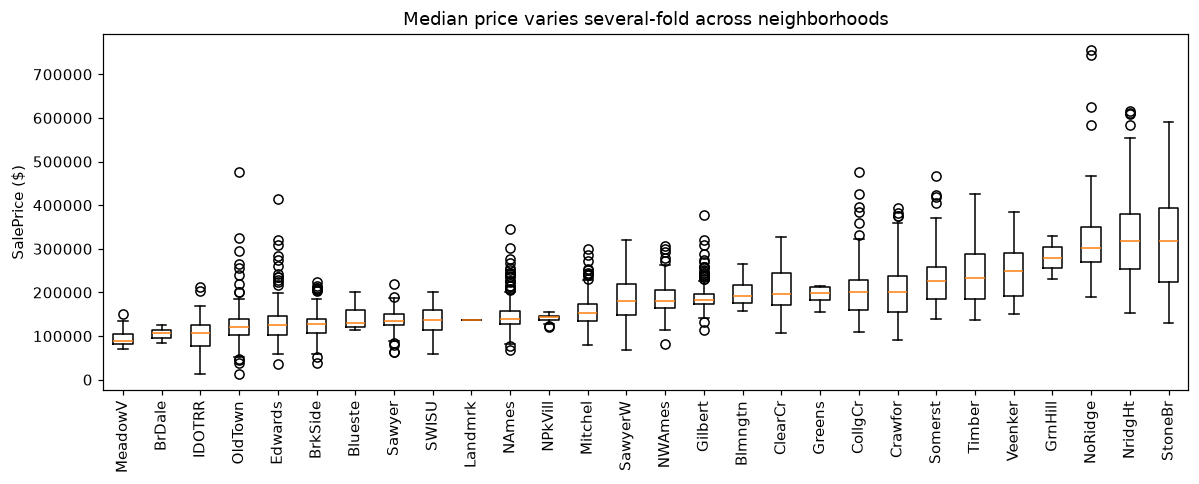

Neighborhood has 28 categories
cheapest median :    MeadowV  $88,250
dearest  median :    StoneBr  $319,000


In [13]:
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values()
data = [df.loc[df["Neighborhood"] == n, "SalePrice"] for n in order.index]

plt.figure(figsize=(11, 4.5))
plt.boxplot(data, tick_labels=order.index)
plt.xticks(rotation=90)
plt.ylabel("SalePrice ($)")
plt.title("Median price varies several-fold across neighborhoods")
plt.tight_layout(); plt.show()

print(f"Neighborhood has {df['Neighborhood'].nunique()} categories")
print(f"cheapest median : {order.index[0]:>10s}  ${order.iloc[0]:,.0f}")
print(f"dearest  median : {order.index[-1]:>10s}  ${order.iloc[-1]:,.0f}")

**Finding.** Median price ranges from **\$88,250** (`MeadowV`) to **\$319,000** (`StoneBr`) -
a factor of about 3.6, with the boxes showing that the spread *within* an expensive
neighborhood is also much wider. `Neighborhood` is clearly informative, but it has
**28 categories**, so one-hot encoding it adds 28 columns. Given the spread, that is worth it.

### Ordered ratings: order carries the information

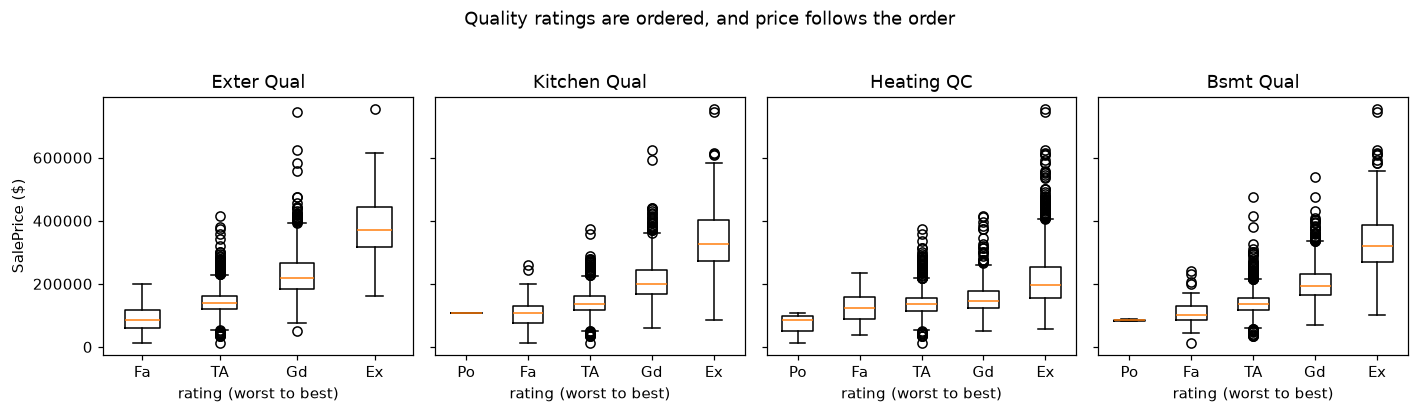

In [14]:
qual_order = ["Po", "Fa", "TA", "Gd", "Ex"]
rating_cols = ["Exter Qual", "Kitchen Qual", "Heating QC", "Bsmt Qual"]

fig, ax = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
for a, col in zip(ax, rating_cols):
    present = [c for c in qual_order if c in df[col].dropna().unique()]
    a.boxplot([df.loc[df[col] == c, "SalePrice"] for c in present], tick_labels=present)
    a.set_title(col); a.set_xlabel("rating (worst to best)")
ax[0].set_ylabel("SalePrice ($)")
plt.suptitle("Quality ratings are ordered, and price follows the order", y=1.03)
plt.tight_layout(); plt.show()

**Finding (supports Q4).** These columns use the scale `Po < Fa < TA < Gd < Ex`, and median
price rises along it every time. One-hot encoding would discard that ordering and spend four
columns rediscovering it. **Ordinal encoding with an explicitly stated order** preserves it in
a single column - and it lets the "absent" category (no basement, no fireplace) sit naturally
at position 0, below "poor".

This is the main reason Step 3 uses *four* preprocessing routes instead of the usual two.

---

## 1.9 Step 1 decision checkpoint

Everything above exists to justify one of these decisions:

| Observation (evidence) | Decision | Step |
|---|---|---|
| `Order`, `PID` unique per row; `PID` r = -0.25 is a location proxy | drop both | 4 |
| `MS SubClass` is numeric but non-monotonic in price | treat as categorical | 3 |
| `SalePrice` skew = 1.74, log-skew = -0.01 | keep dollars for interpretable RMSE; log is the Q7 proposal | 6 |
| 157/157 garage-NaN rows have `Garage Area == 0` | NaN = absence → fill `"None"` | 3 |
| 1,745 of 1,775 `Mas Vnr Type` NaN have `Area == 0` | NaN = absence, not a broken column | 3 |
| `Lot Frontage` 16.7% NaN, no related column explains it | genuine unknown → median-impute from train | 3 |
| quality ratings are monotonic in price | ordinal-encode with stated order | 3 |
| `Neighborhood` spans 3.6x in median price, 28 levels | one-hot encode, accept the width | 3 |
| `Garage Cars` ≈ `Garage Area`; basement SF columns sum to the total | build one combined size feature | 4 |
| `Year Built` correlates 0.56 with price | convert years to ages at sale | 4 |
| 3 of 5 houses > 4,000 sq ft are `Partial` sales | drop those 3 **from training only**; keep `Sale Condition` as a feature | 4 |
| numerical features span wildly different scales | standardise inside the pipeline | 3 |

Proceed to `02_modeling.ipynb` for Steps 2-6.
